# TECHIN 513 Final Project — Music-to-Imagine
**Team 18: Taya Li & Yilu Huang**

Pipeline: Audio Input → Preprocessing → Feature Extraction → Energy Labeling → ML Classification → Visual Mapping

## Step 1: Load Audio (Test Single File)

In [1]:
import librosa
import numpy as np
import os

BASE_DIR = os.path.dirname(os.path.abspath(__file__)) if '__file__' in dir() else os.getcwd()
DATASET_PATH = os.path.join(BASE_DIR, '..', 'Data', 'genres_original')
CSV_PATH = os.path.join(BASE_DIR, '..', 'Data', 'features.csv')

# Test: load one song
genre = "rock"
filename = os.listdir(f"{DATASET_PATH}/{genre}")[0]
filepath = f"{DATASET_PATH}/{genre}/{filename}"

y, sr = librosa.load(filepath, sr=22050, mono=True)
print(f"Loaded successfully: {filename}")
print(f"Sample rate: {sr}")
print(f"Duration: {len(y)/sr:.1f} seconds")

Loaded successfully: rock.00011.wav
Sample rate: 22050
Duration: 30.0 seconds


## Step 2 & 3: Feature Extraction (19 features)

In [2]:
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=22050, mono=True)
    
    # 1. RMS Energy（响度/强度）
    rms = np.mean(librosa.feature.rms(y=y))
    
    # 2. Zero Crossing Rate（噪声感）
    zcr = np.mean(librosa.feature.zero_crossing_rate(y=y))
    
    # 3. Spectral Centroid（音色亮度）
    centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    
    # 4. Spectral Flux（动态变化）
    flux = np.mean(librosa.onset.onset_strength(y=y, sr=sr))
    
    # 5. Tempo（节拍速度）
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    tempo = float(np.atleast_1d(tempo)[0])
    
    # 6-18. 13 MFCCs（音色/timbre）
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc_means = list(np.mean(mfcc, axis=1))
    
    # 总共 19 个特征
    return [rms, zcr, centroid, flux, tempo] + mfcc_means

# 测试单首歌
features = extract_features(filepath)
print(f"RMS Energy:         {features[0]:.6f}")
print(f"Zero Crossing Rate: {features[1]:.6f}")
print(f"Spectral Centroid:  {features[2]:.2f}")
print(f"Spectral Flux:      {features[3]:.6f}")
print(f"Tempo:              {features[4]:.2f} BPM")
print(f"MFCCs (1-13):       {[round(m,2) for m in features[5:]]}")
print(f"\n总特征数: {len(features)}")

RMS Energy:         0.123355
Zero Crossing Rate: 0.054330
Spectral Centroid:  1537.47
Spectral Flux:      1.388435
Tempo:              117.45 BPM
MFCCs (1-13):       [np.float32(-169.68), np.float32(119.11), np.float32(7.16), np.float32(53.43), np.float32(4.13), np.float32(23.13), np.float32(-5.72), np.float32(24.99), np.float32(-9.33), np.float32(13.47), np.float32(-14.28), np.float32(5.96), np.float32(-13.6)]

总特征数: 18


## Step 4: Batch Processing (All 999 Tracks)

In [4]:
columns = ['genre', 'filename', 'rms', 'zcr', 'centroid', 'flux', 'tempo'] + \
          [f'mfcc_{i}' for i in range(1, 14)]

rows = []
genres = os.listdir(DATASET_PATH)
genres = [g for g in genres if os.path.isdir(f"{DATASET_PATH}/{g}")]

for genre in sorted(genres):
    genre_path = f"{DATASET_PATH}/{genre}"
    files = sorted(os.listdir(genre_path))
    for fname in files:
        if not fname.endswith('.wav'):
            continue
        fpath = f"{genre_path}/{fname}"
        try:
            feats = extract_features(fpath)
            rows.append([genre, fname] + feats)
        except Exception as e:
            print(f"跳过 {fname}: {e}")

df = pd.DataFrame(rows, columns=columns)
df.to_csv('../Data/features.csv', index=False)
print(f"处理完成: {len(df)} 首歌")
print(df.head())

/var/folders/gr/5yg_hd4n6zn30lb40jmvtgs80000gn/T/ipykernel_43632/3426054986.py:2: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=22050, mono=True)
/opt/anaconda3/envs/techin513/lib/python3.11/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


跳过 jazz.00054.wav: 


NameError: name 'pd' is not defined

## Step 5: Energy Label Design (RMS + Tempo Percentile)

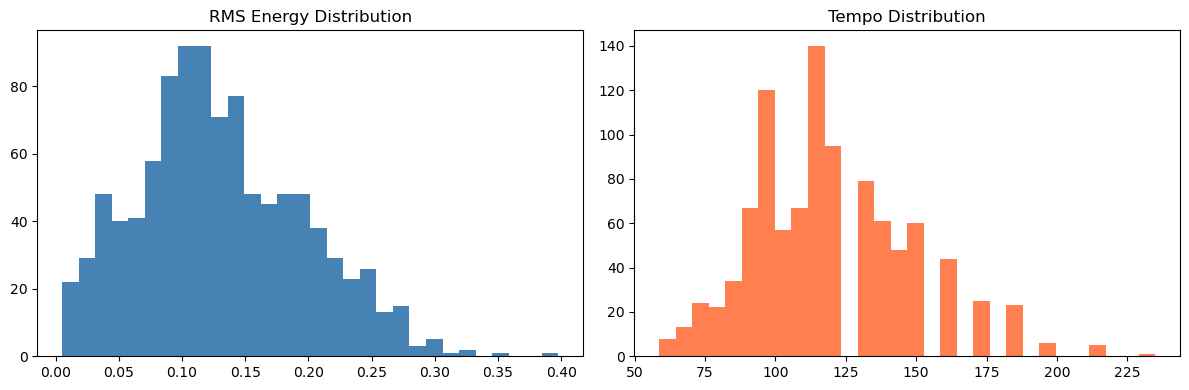

RMS thresholds:   low=0.0978, high=0.1533
Tempo thresholds: low=103.36, high=129.20 BPM

标签分布:
energy_label
Medium    361
High      347
Low       291
Name: count, dtype: int64


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# 直接读取已有的 features.csv
df = pd.read_csv('../Data/features.csv')

# 分布图
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['rms'], bins=30, color='steelblue')
axes[0].set_title('RMS Energy Distribution')
axes[1].hist(df['tempo'], bins=30, color='coral')
axes[1].set_title('Tempo Distribution')
plt.tight_layout()
os.makedirs('../Data/figures', exist_ok=True)
plt.savefig('../Data/figures/feature_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# 百分位阈值
rms_low, rms_high = df['rms'].quantile(0.33), df['rms'].quantile(0.67)
tempo_low, tempo_high = df['tempo'].quantile(0.33), df['tempo'].quantile(0.67)
print(f"RMS thresholds:   low={rms_low:.4f}, high={rms_high:.4f}")
print(f"Tempo thresholds: low={tempo_low:.2f}, high={tempo_high:.2f} BPM")

def label_energy(row):
    rms_score = 0 if row['rms'] < rms_low else (1 if row['rms'] < rms_high else 2)
    tempo_score = 0 if row['tempo'] < tempo_low else (1 if row['tempo'] < tempo_high else 2)
    avg = (rms_score + tempo_score) / 2
    if avg < 0.75:
        return 'Low'
    elif avg < 1.5:
        return 'Medium'
    else:
        return 'High'

df['energy_label'] = df.apply(label_energy, axis=1)
print("\n标签分布:")
print(df['energy_label'].value_counts())

## Step 6: ML Classification (LR / SVM / Random Forest)


=== Logistic Regression ===
              precision    recall  f1-score   support

        High       0.83      0.84      0.84        70
         Low       0.88      0.84      0.86        58
      Medium       0.73      0.74      0.73        72

    accuracy                           0.81       200
   macro avg       0.81      0.81      0.81       200
weighted avg       0.81      0.81      0.81       200



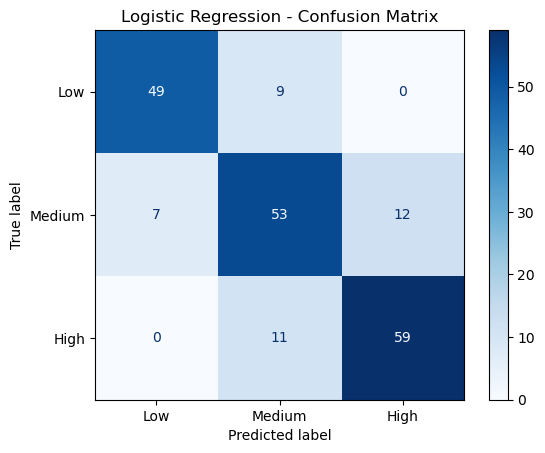


=== SVM ===
              precision    recall  f1-score   support

        High       0.90      0.86      0.88        70
         Low       0.84      0.72      0.78        58
      Medium       0.70      0.81      0.75        72

    accuracy                           0.80       200
   macro avg       0.81      0.80      0.80       200
weighted avg       0.81      0.80      0.80       200



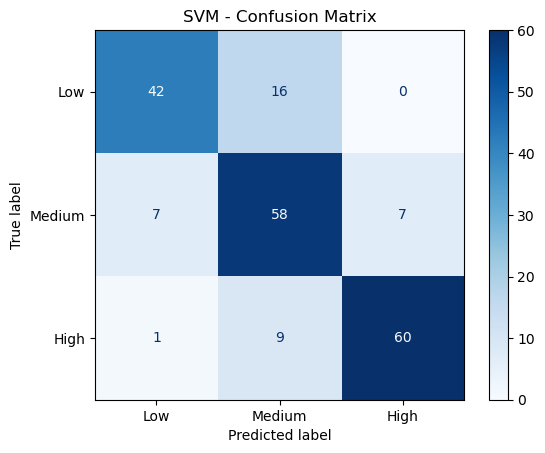


=== Random Forest ===
              precision    recall  f1-score   support

        High       0.97      1.00      0.99        70
         Low       1.00      0.97      0.98        58
      Medium       0.97      0.97      0.97        72

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200



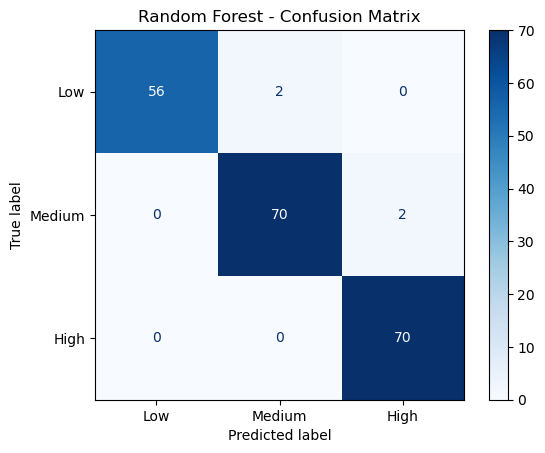

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

feature_cols = ['rms', 'zcr', 'centroid', 'flux', 'tempo'] + [f'mfcc_{i}' for i in range(1, 14)]

X = df[feature_cols].values
y = df['energy_label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred, labels=['Low', 'Medium', 'High'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Low', 'Medium', 'High'])
    disp.plot(cmap='Blues')
    plt.title(f'{name} - Confusion Matrix')
    safe_name = name.lower().replace(' ', '_')
    os.makedirs('../Data/figures', exist_ok=True)
    plt.savefig(f'../Data/figures/cm_{safe_name}.png', dpi=150, bbox_inches='tight')
    plt.show()